In [3]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
from lattice_s32 import SpinConfiguration

nx = 4
ny = 2
n = nx * ny

def get_m_vs_U(_delta = 1., _lambda = 1., S_z_tot = 0, print = False):
    sc = SpinConfiguration(nx, ny, int(3*n/2) + S_z_tot, lowest_eignstates=1, delta=_delta, lamb=_lambda, print_data=False)

    mag = []
    _min = -3
    _max = 6
    steps = 30*(_max - _min) + 1
    u_range = np.logspace(_min, _max, base = 10, num = steps)

    rotation_map = np.array( [ [ (1 + (-1)**(x + y))/2 for x in range(nx) ] for y in range(ny) ] ).reshape((ny, nx))

    for u in tqdm(u_range, disable = not print):
        # U that should be used is up to 1e5
        sc.generate_hamiltonian(U = u)
        sc.get_eigva_eigve(6)
        _, gs_state = sc.get_ground_state()

        m : np.float64 = 0

        for repr, ii in sc.representatives.items():
            config = sc.map_int_to_config(repr)
            m += np.square(np.abs(gs_state[ii])) * np.mean((config - 1) * (config - 2))
            #rotated_cfg = config * rotation_map + (3 - config) * (1 - rotation_map)
            #m += np.square(np.abs(gs_state[ii])) * np.mean(rotated_cfg * np.roll(rotated_cfg, (-1, 0), axis= (0,1)))
            #m += np.square(np.abs(gs_state[ii])) * np.mean(rotated_cfg * np.roll(rotated_cfg, (0, -1), axis= (0,1)))
            #m += np.square(np.abs(gs_state[ii])) * (np.mean(rotated_cfg) - 3/2)
        
        mag.append(m)
    
    return u_range, mag


In [ ]:
"""
delta = 2.
lamb = 0.
u_range, M_1 = get_m_vs_U(delta, lamb)
m_1 = np.mean((np.sqrt(M_1) * u_range)[-10:])
print(m_1)
u_range, M_2 = get_m_vs_U(delta, lamb, 1)
m_2 = np.mean((np.sqrt(M_2) * u_range)[-10:])
print(m_2)
"""

delta = 1.
lamb = 0.
u_range, M_1 = get_m_vs_U(delta, lamb)
m_1 = np.mean((np.sqrt(M_1) * u_range)[-10:])
#m_1 = np.mean(((M_1) * u_range)[-10:])
print(m_1)
u_range, M_2 = get_m_vs_U(delta, lamb, 1)
m_2 = np.mean((np.sqrt(M_2) * u_range)[-10:])
#m_2 = np.mean(((M_2) * u_range)[-10:])
print(m_2)

1.6007947503304831
2.2333615847918487
2.233361584796024


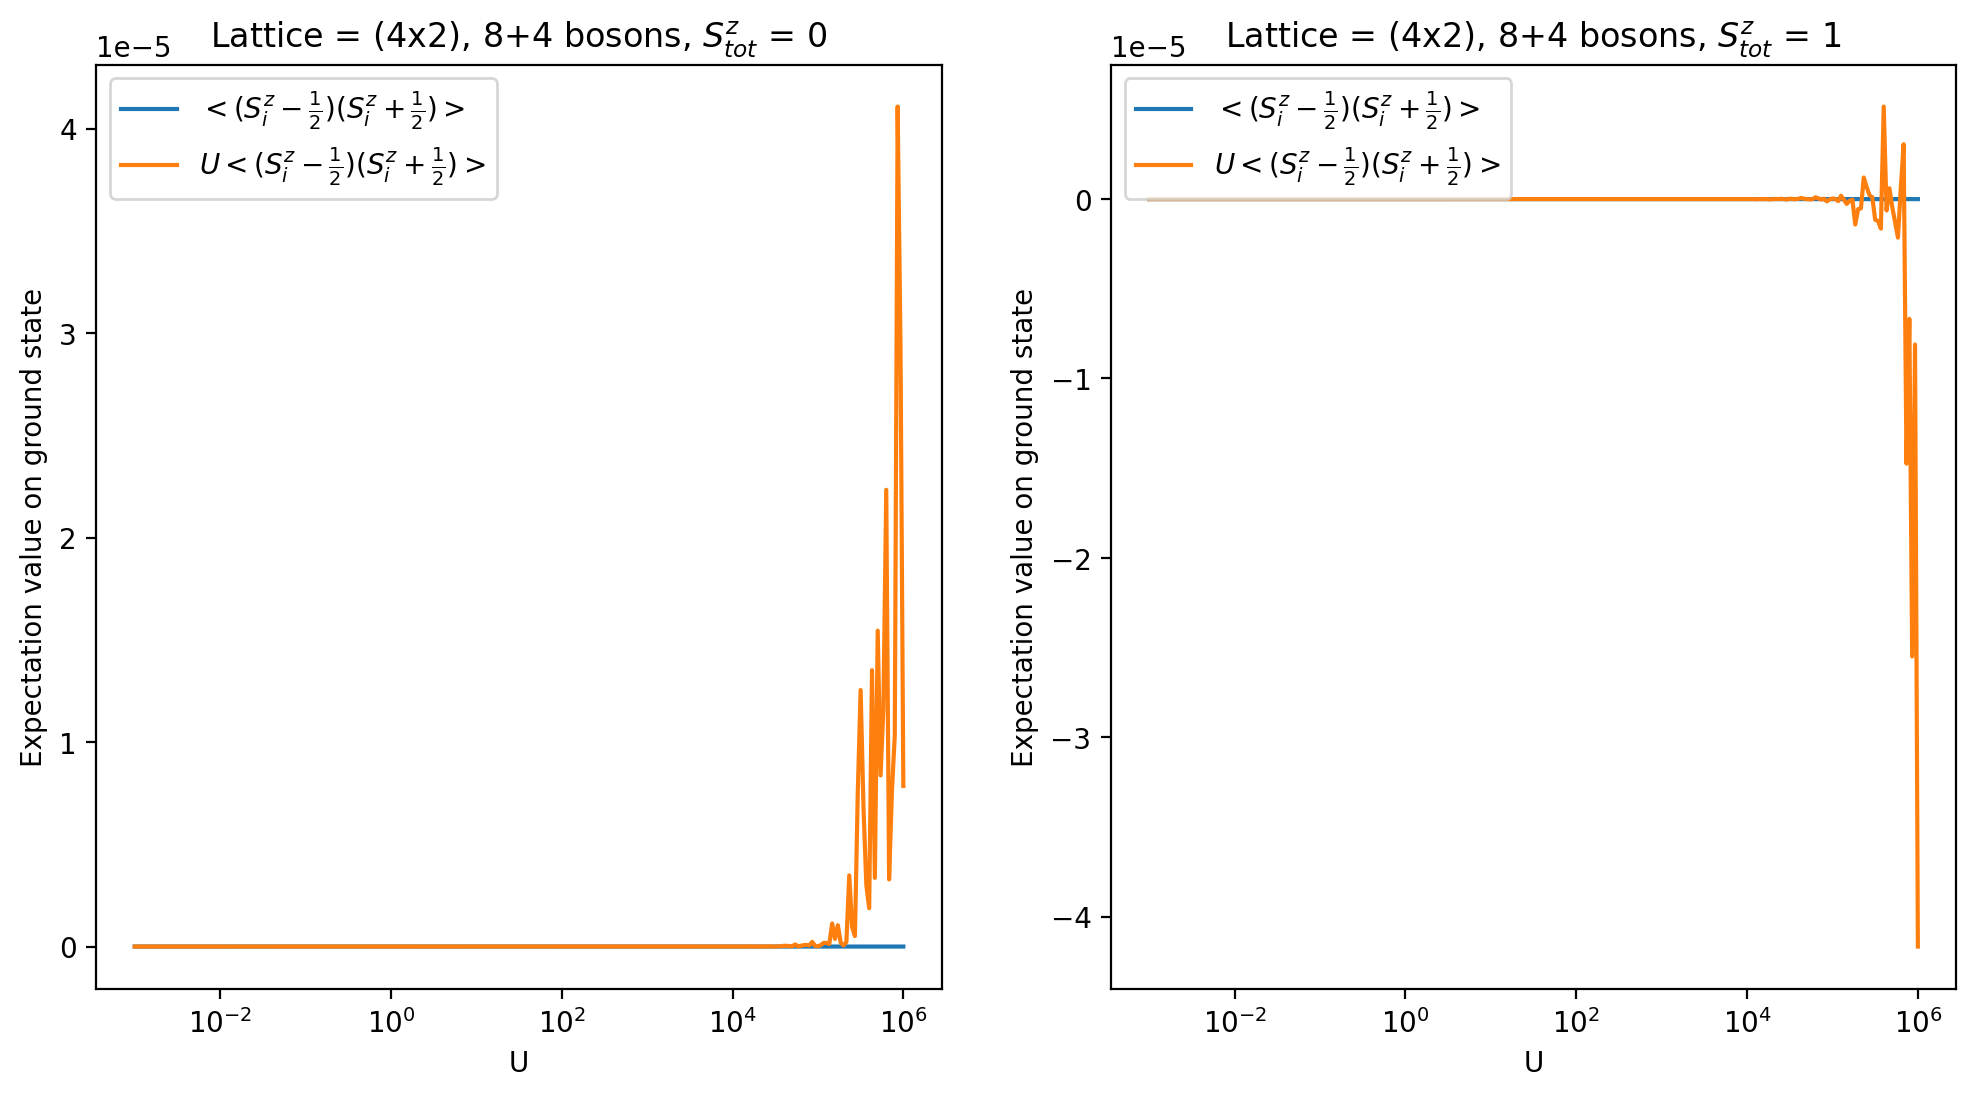

In [46]:
fig = plt.figure(figsize = (12, 6), dpi = 200)
plt.subplot(1, 2, 1)
#plt.plot(u_range, M_1, label=r'$m_s$')
#plt.plot(u_range, M_1, label=r'$<\sum_{<ij>}n_i n_j>$')
plt.plot(u_range, np.abs(M_1), label=r'$<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>$')
plt.plot(u_range, np.abs(M_1 * u_range), label=r'$U<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>$')
#plt.plot(u_range, np.sqrt(np.abs(M_1)) * u_range, label=r'$U\cdot\sqrt{<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>}$')
#plt.hlines(m_1, 1, 1e5, 'gray', '--')
plt.xscale('log')
plt.legend()
plt.xlabel('U')
plt.title(rf'Lattice = ({nx}x{ny}), {n}+{int(n/2)} bosons' + r', $S^z_{tot}$ = 0')
plt.ylabel('Expectation value on ground state')

plt.subplot(1, 2, 2)
#plt.plot(u_range, M_2, label=r'$m_s$')
#plt.plot(u_range, M_2, label=r'$<\sum_{<ij>}n_i n_j>$')
plt.plot(u_range, M_2, label=r'$<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>$')
plt.plot(u_range, M_2 * u_range, label=r'$U<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>$')
#plt.plot(u_range, np.sqrt(np.abs(M_2)) * u_range, label=r'$U\cdot\sqrt{<(S^z_i - \frac{1}{2})(S^z_i + \frac{1}{2})>}$')
#plt.hlines(m_2, 1, 1e5, 'gray', '--')
plt.xscale('log')
plt.legend()
plt.xlabel('U')
plt.title(rf'Lattice = ({nx}x{ny}), {n}+{int(n/2)} bosons' + r', $S^z_{tot}$ = 1')
plt.ylabel('Expectation value on ground state')

plt.show()

In function of delta

In [24]:
from lattice_s32 import SpinConfiguration

nx = 6
ny = 2
n = nx * ny

def get_m_vs_U(_delta = 1., _lambda = 1., S_z_tot = 0, sc : SpinConfiguration = None):
    if sc is None:
        sc = SpinConfiguration(nx, ny, int(3*n/2) + S_z_tot, lowest_eignstates=1, delta=_delta, lamb=_lambda, print_data=False)
    else:
        sc.delta = _delta
        sc.lamb = _lambda

    sc.generate_hamiltonian(U = 1e4)
    sc.get_eigva_eigve(6)
    _, gs_state = sc.get_ground_state()

    m = 0

    for repr, ii in sc.representatives.items():
        config = sc.map_int_to_config(repr)
        m += np.square(np.abs(gs_state[ii])) * np.mean((config - 1) * (config - 2))

    return m, sc


In [25]:
d_range = np.arange(1., 3.001, 0.1)
#d_range = np.array([1., 1.35, 1.74, 2.])
print(d_range)

masses = []

sc = None
sc_1 = None

lamb = 0.

for delta in tqdm(d_range):
    M_1, sc = get_m_vs_U(delta, lamb, sc=sc)
    m_1 = np.sqrt(M_1) * 1e4
    M_2, sc_1 = get_m_vs_U(delta, lamb, 1, sc = sc_1)
    m_2 = np.sqrt(M_2) * 1e4
    masses.append(m_2 - m_1)
    #masses.append(m_2)


[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3. ]


100%|██████████| 21/21 [32:05<00:00, 91.68s/it] 


In [ ]:
matrix = np.zeros( (len(masses), 2) )
matrix[:, 0] = d_range
matrix[:, 1] = masses
print(matrix)
#np.savetxt('masses_vs_d.txt', matrix)


[[1.         0.46203512]
 [1.1        0.47505681]
 [1.2        0.48606217]
 [1.3        0.4945969 ]
 [1.4        0.50276049]
 [1.5        0.50927769]
 [1.6        0.51494359]
 [1.7        0.51976804]
 [1.8        0.52411338]
 [1.9        0.52758418]
 [2.         0.53067596]
 [2.1        0.53332555]
 [2.2        0.53574595]
 [2.3        0.53797117]
 [2.4        0.53988822]
 [2.5        0.54159745]
 [2.6        0.54321443]
 [2.7        0.54468394]
 [2.8        0.54610372]
 [2.9        0.54698404]
 [3.         0.54782283]]


[-0.12844024  0.59342138]


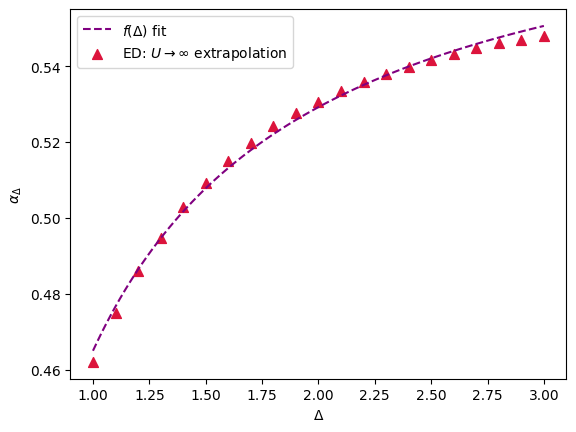

In [47]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.optimize as op

matrix = np.loadtxt('masses_vs_d.txt')
d_range = matrix[:, 0]
masses = matrix[:, 1]

def func(pars, drange = d_range):
    a, b = pars
    return a / drange + b

def fit(pars):
    return np.sum( np.square(func(pars) - masses) )

fun = op.minimize(fit, [-.1, 2.])
print(fun.x)

_cont_d_range = np.linspace(np.min(d_range), np.max(d_range), 101)
y = func(fun.x, drange = _cont_d_range)
plt.plot(_cont_d_range, y, c='purple', ls='--', label = r'$f(\Delta)$ fit')
plt.scatter(d_range, masses, marker='^', s=50, c='crimson', label=r'ED: $U\to\infty$ extrapolation')
#plt.ylim([0, .32])
plt.ylabel(r'$\alpha_\Delta$')
plt.xlabel(r'$\Delta$')
plt.legend()
plt.show()

In function of lambda

In [5]:
from lattice_s32 import SpinConfiguration
import numpy as np
from tqdm import tqdm

nx = 6
ny = 2
n = nx * ny

def get_m_vs_U(_delta = 1., _lambda = 1., S_z_tot = 0, sc : SpinConfiguration = None):
    if sc is None:
        sc = SpinConfiguration(nx, ny, int(3*n/2) + S_z_tot, lowest_eignstates=1, delta=_delta, lamb=_lambda, print_data=False)
    else:
        sc.delta = _delta
        sc.lamb = _lambda

    sc.generate_hamiltonian(U = 1e4)
    sc.get_eigva_eigve(6)
    _, gs_state = sc.get_ground_state()

    m = 0

    for repr, ii in sc.representatives.items():
        config = sc.map_int_to_config(repr)
        m += np.square(np.abs(gs_state[ii])) * np.mean((config - 1) * (config - 2))

    return m, sc


In [6]:
l_range = np.linspace(0., 1., 21)
l_range = [0., .5, .75, 1.]
print(l_range)

masses = []

sc = None
sc_1 = None

delta = 2.

for var in tqdm(l_range):
    M_1, sc = get_m_vs_U(delta, var, sc=sc)
    m_1 = np.sqrt(M_1) * 1e4
    M_2, sc_1 = get_m_vs_U(delta, var, 1, sc = sc_1)
    m_2 = np.sqrt(M_2) * 1e4
    masses.append(m_2 - m_1)
    #masses.append(m_1)


[0.0, 0.5, 0.75, 1.0]


100%|██████████| 4/4 [06:29<00:00, 97.33s/it] 


In [7]:
matrix = np.zeros( (len(masses), 2) )
matrix[:, 0] = l_range
matrix[:, 1] = masses
print(matrix)
#np.savetxt('masses_vs_l.txt', matrix)


[[0.         0.53058855]
 [0.5        0.4903863 ]
 [0.75       0.43196668]
 [1.         0.2692908 ]]


[[0.         0.46181928]
 [0.05       0.45587005]
 [0.1        0.4494667 ]
 [0.15       0.44339775]
 [0.2        0.43555605]
 [0.25       0.42727012]
 [0.3        0.4180427 ]
 [0.35       0.40791467]
 [0.4        0.3962462 ]
 [0.45       0.38483562]
 [0.5        0.37003794]
 [0.55       0.35488057]
 [0.6        0.33758612]
 [0.65       0.31905736]
 [0.7        0.29837974]
 [0.75       0.27673808]
 [0.8        0.25467846]
 [0.85       0.23465277]
 [0.9        0.21776337]
 [0.95       0.20779815]
 [1.         0.20619835]]


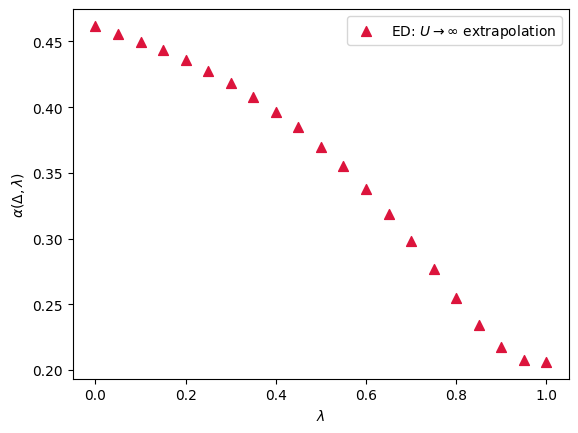

In [ ]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.optimize as op

#matrix = np.loadtxt('masses_vs_l.txt')
l_range = matrix[:, 0]
masses = matrix[:, 1]

print(matrix)

plt.scatter(l_range, masses, marker='^', s=50, c='crimson', label=r'ED: $U\to\infty$ extrapolation')
#plt.ylim([0, .32])
plt.ylabel(r'$\alpha(\Delta, \lambda)$')
plt.xlabel(r'$\lambda$')
plt.legend()
plt.show()